In [1]:




# You’re tasked with optimising an ML model by tuning six hyperparameters, 
# for example learning rate, regularisation strength or number of hidden layers. 
# The function you’re maximising is the model’s performance score (such as accuracy or F1), 
# but since the relationship between inputs and output isn’t known, it’s treated as a black-box function. 

# Because this is a commonly used model, you might benefit from researching best practices or literature to guide your initial search space. 
# Your goal is to find the combination of hyperparameters that yields the highest possible performance.



In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X = np.load('initial_inputs.npy')
y = np.load('initial_outputs.npy')

print('-- inputs X ---')
print(X)
print("X shape=",X.shape)

print('-- outputs y ---')
print(y)
print("y shape=",y.shape)

# Set random seed for reproducibility
np.random.seed(42)

-- inputs X ---
[[0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
 [0.54300258 0.9246939  0.34156746 0.64648585 0.71844033 0.34313266]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.63021764 0.8380969  0.68001305 0.73189509 0.52673671 0.34842921]
 [0.76491917 0.25588292 0.60908422 0.21807904 0.32294277 0.09579366]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.19525188 0.07922665 0.55458046 0.17056682 0.01494418 0.10703171]
 [0.64230298 0.83687455 0.02179269 0.10148801 0.68307083 0.6924164 ]
 [0.78994255 0.19554501 0.57562333 0.07365919 0.25904917 0.05109986]
 [0.52849733 0.45742436 0.36009569 0.36204551 0.81689098 0.63747637]
 [0.72261522 0.01181284 0.06364591 0.16517311 0.07924415 0.35995166]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.94245084 0.37743962 0.48612233 0.22879108 0.08263175 0.71195755]
 [0.14864702 0.033

In [5]:
df = pd.DataFrame(X, columns=["x1","x2","x3","x4","x5","x6"])
df['y'] = y
df = df.sort_values(by='y', ascending=False)
df

,x1,x2,x3,x4,x5,x6,y
6,0.057896,0.491672,0.247422,0.218118,0.420428,0.730970,1.364968
24,0.881647,0.204450,0.414474,0.420385,0.264915,0.730660,0.675142
14,0.148647,0.033943,0.728806,0.316066,0.021769,0.516918,0.611526
0,0.272624,0.324495,0.897109,0.832951,0.154063,0.795864,0.604433
1,0.543003,0.924694,0.341567,0.646486,0.718440,0.343133,0.562753
25,0.066611,0.528045,0.816095,0.961017,0.086509,0.777788,0.516457
23,0.175978,0.624416,0.295542,0.469553,0.097770,0.728141,0.475396
16,0.417626,0.064100,0.245669,0.559041,0.191531,0.254641,0.274893
4,0.630218,0.838097,0.680013,0.731895,0.526737,0.348429,0.273047
13,0.942451,0.377440,0.486122,0.228791,0.082632,0.711958,0.268400


In [39]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from scipy.stats import norm
import warnings
from sklearn.exceptions import ConvergenceWarning

# Put this at the very top of your script
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# Simplify to just Matern
kernel = Matern(
    length_scale=[0.5] * 6, 
    length_scale_bounds=(0.4, 4.0), # Keeping your restrictive bounds
    nu=1.5
)

# 2. Set alpha explicitly to handle noise
# alpha=0.01 implies we expect a standard deviation of 0.1 in the scores
gp = GaussianProcessRegressor(
    kernel=kernel, 
    alpha=0.2,            # Increased noise floor to prevent overfitting
    normalize_y=True, 
    n_restarts_optimizer=15
)
gp.fit(X, y)

print(f"Optimized Kernel: {gp.kernel_}")
print(f"Training R^2 Score: {gp.score(X, y)}")
print(f"Total variance accounted for as noise: {gp.alpha}")

# Optimized Kernel: Matern(length_scale=[0.84, 4, 4, 0.442, 0.4, 0.421], nu=1.5)
# Training R^2 Score: 0.9375136391096723
# Total variance accounted for as noise: 0.2

Optimized Kernel: Matern(length_scale=[0.84, 4, 4, 0.442, 0.4, 0.421], nu=1.5)
Training R^2 Score: 0.9375136210844796
Total variance accounted for as noise: 0.2


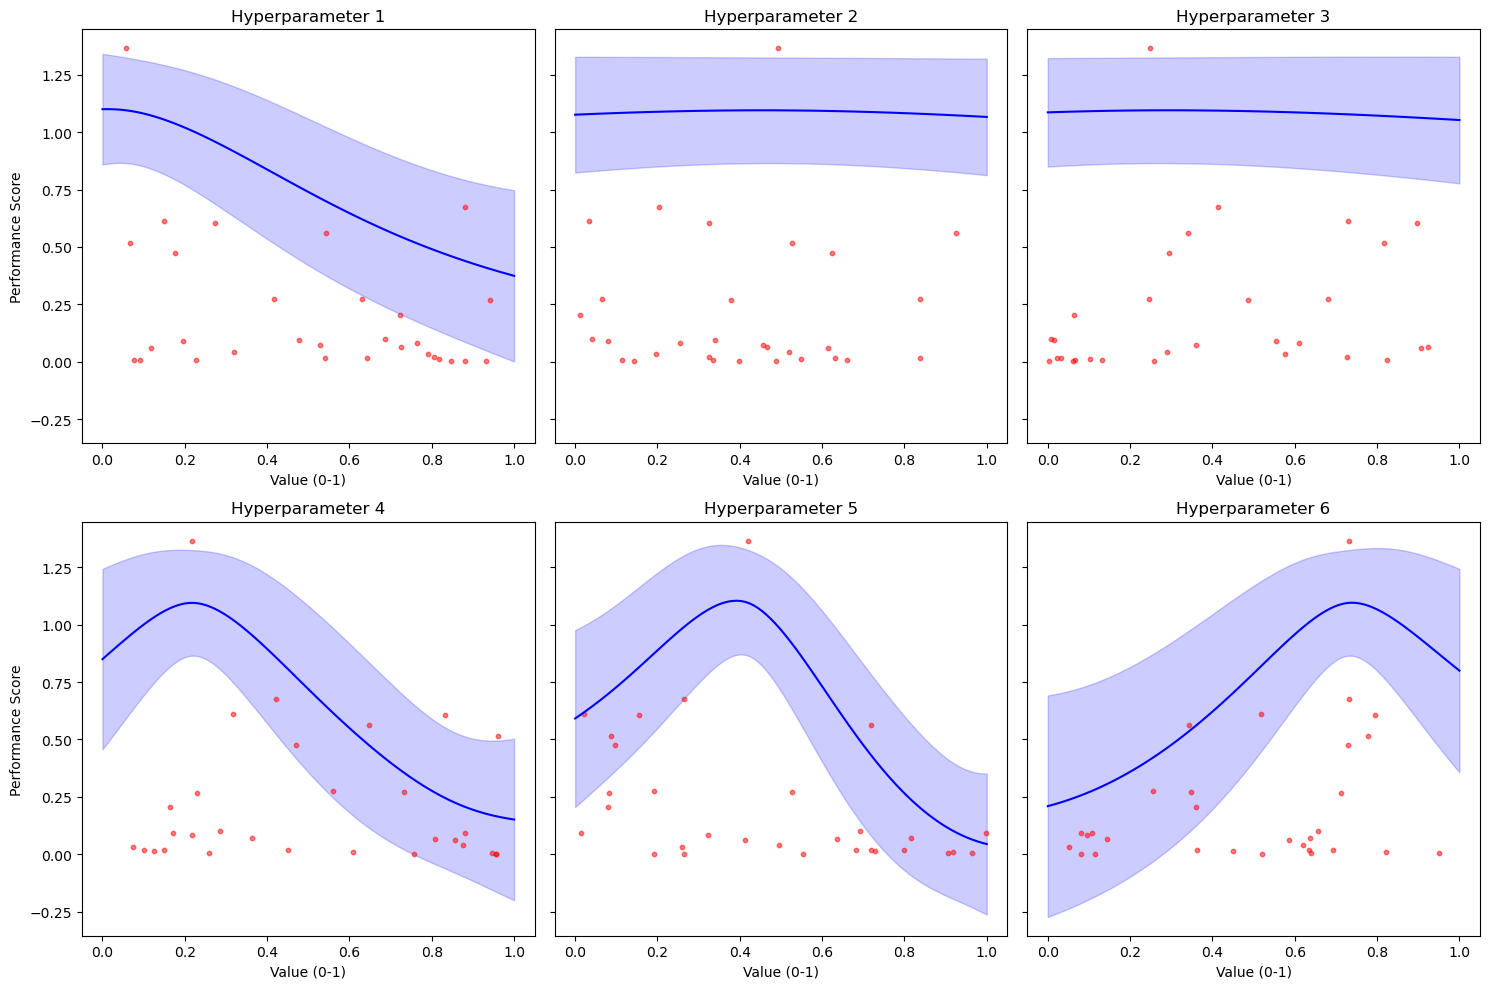

In [18]:
import matplotlib.pyplot as plt

def plot_6d_slices(gp, X_data, y_data):
    # 1. Find the best point so far to use as our "anchor"
    best_idx = np.argmax(y_data)
    best_x = X_data[best_idx]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharey=True)
    axes = axes.flatten()
    
    x_line = np.linspace(0, 1, 100)
    
    for i in range(6):
        # Create a grid where only dimension 'i' varies
        X_slice = np.tile(best_x, (100, 1))
        X_slice[:, i] = x_line
        
        # Predict posterior mean and std dev
        mu, sigma = gp.predict(X_slice, return_std=True)
        
        # Plot
        ax = axes[i]
        ax.plot(x_line, mu, 'b-', label='GP Mean')
        ax.fill_between(x_line, mu - 1.96*sigma, mu + 1.96*sigma, color='blue', alpha=0.2, label='95% Conf.')
        
        # Plot the actual data points (projected onto this axis)
        ax.scatter(X_data[:, i], y_data, c='red', s=10, alpha=0.5, label='Data')
        
        ax.set_title(f"Hyperparameter {i+1}")
        ax.set_xlabel("Value (0-1)")
        if i % 3 == 0: ax.set_ylabel("Performance Score")

    plt.tight_layout()
    plt.show()

plot_6d_slices(gp, X, y)

In [19]:

# What to look for in these plots:
# Flat Lines (Dim 2 & 3): You will likely see almost horizontal lines here. 
  # This confirms the "length_scale=4" finding—these parameters don't move the needle.
# Curves (Dim 1, 4, 5, 6): Look for peaks. If a peak is at the edge (0.0 or 1.0), 
  # it suggests you might need to expand your search space in that direction.
# Shaded Area (Uncertainty): Where the blue cloud is wide, the model is "guessing." 
  # Where it pinches close to the line, the model is confident.






In [20]:
def upper_confidence_bound(mu, sigma, kappa=2.0):
    """
    kappa = 1.96  -> 95% confidence (Balanced)
    kappa = 2.576 -> 99% confidence (More Exploration)
    """
    return mu + kappa * sigma
    
def expected_improvement(mu, sigma, y_best, xi=0.01):
    with np.errstate(divide='warn'):
        improvement = mu - y_best - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

# Predict
X_grid = np.random.uniform(0, 1, size=(10000, 6))
mu, sigma = gp.predict(X_grid, return_std=True)

sigma = sigma.reshape(-1, 1)
mu = mu.reshape(-1, 1)
y_best = y.max()

In [24]:
xi=0.01
ei_values = expected_improvement(mu, sigma, y_best, xi)

# Get the next best point
ei_next_idx = np.argmax(ei_values)
ei_next_query = X_grid[ei_next_idx]

print(f"expected_improvement with xi: {xi}")
print(f"Current Best y: {y.max()}")
print(f"Suggested next: {ei_next_query}")

# best combination so far 
#     x1      x2        x3          x4         x5            x6          y
# 0.057896	0.491672	0.247422	0.218118	0.420428	0.730970	1.364968
# Suggested next: 
#     x1          x2          x3         x4       x5        x6
# [0.02559151 0.83149835 0.79196305 0.13285251 0.33530564 0.8847962 ]

expected_improvement with xi: 0.01
Current Best y: 1.3649683044991994
Suggested next: [0.02559151 0.83149835 0.79196305 0.13285251 0.33530564 0.8847962 ]


In [33]:
# kappa = 2.0 is a great starting point for week 1
kappa=2.0
ucb_values = upper_confidence_bound(mu, sigma, kappa)


ucb_next_idx = np.argmax(ucb_values)
ucb_next_query = X_grid[ucb_next_idx]

print(f"UCB Score with kappa: {kappa}")
print(f"Current Best y: {y.max()}")
print(f"Suggested next: {ucb_next_query}")
# best combination so far 
#     x1      x2        x3          x4         x5            x6          y
# 0.057896	0.491672	0.247422	0.218118	0.420428	0.730970	1.364968
# Suggested next: 
#     x1          x2          x3         x4       x5        x6
# [0.01693075 0.90009681 0.82697883 0.17416768 0.41327318 0.77054898]

# Submit UCB


UCB Score with kappa: 2.0
Current Best y: 1.3649683044991994
Suggested next: [0.01693075 0.90009681 0.82697883 0.17416768 0.41327318 0.77054898]


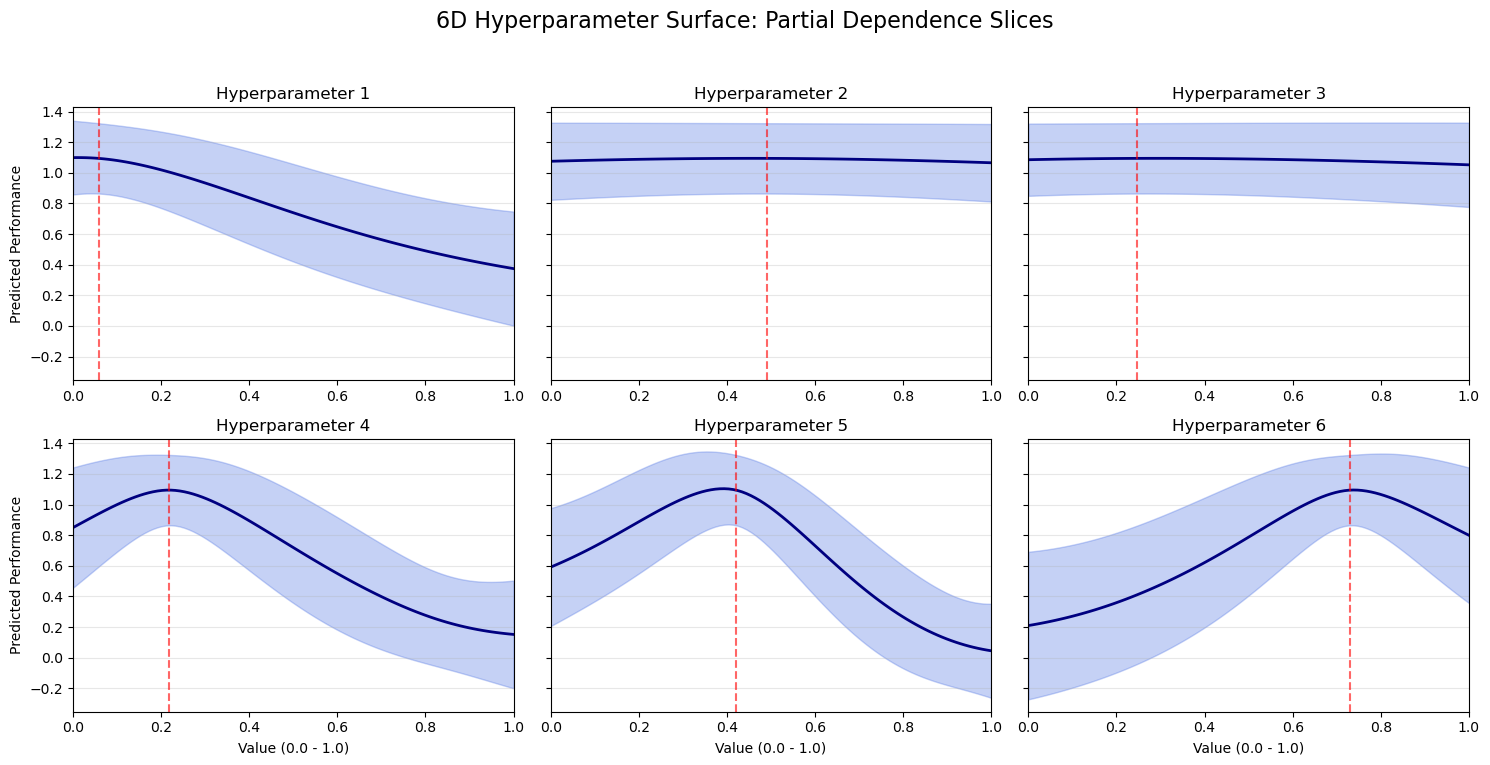

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def plot_6_panel_slice(gp, X_data, y_data):
    # 1. Identify the 'Anchor': The best point we've found so far
    best_idx = np.argmax(y_data)
    best_x = X_data[best_idx]
    
    # 2. Setup the grid (2 rows, 3 columns)
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
    axes = axes.flatten()
    
    # Range to plot (normalized 0 to 1)
    x_range = np.linspace(0, 1, 100)
    
    for i in range(6):
        ax = axes[i]
        
        # Create a test set where only dimension 'i' varies
        # Other 5 dimensions stay fixed at the 'best_x' values
        X_slice = np.tile(best_x, (100, 1))
        X_slice[:, i] = x_range
        
        # Predict Mean and Std Dev from the GP
        mu, sigma = gp.predict(X_slice, return_std=True)
        
        # Plot the GP Posterior
        ax.plot(x_range, mu, color='navy', lw=2, label='GP Mean')
        ax.fill_between(x_range, mu - 1.96*sigma, mu + 1.96*sigma, 
                        color='royalblue', alpha=0.3, label='95% Confidence')
        
        # Add a vertical line for where the 'best' value currently sits
        ax.axvline(best_x[i], color='red', linestyle='--', alpha=0.6, label='Current Best')
        
        ax.set_title(f"Hyperparameter {i+1}")
        ax.set_xlim(0, 1)
        ax.grid(axis='y', alpha=0.3)
        
        if i >= 3: ax.set_xlabel("Value (0.0 - 1.0)")
        if i % 3 == 0: ax.set_ylabel("Predicted Performance")

    plt.suptitle("6D Hyperparameter Surface: Partial Dependence Slices", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Run the plotting function
plot_6_panel_slice(gp, X, y)

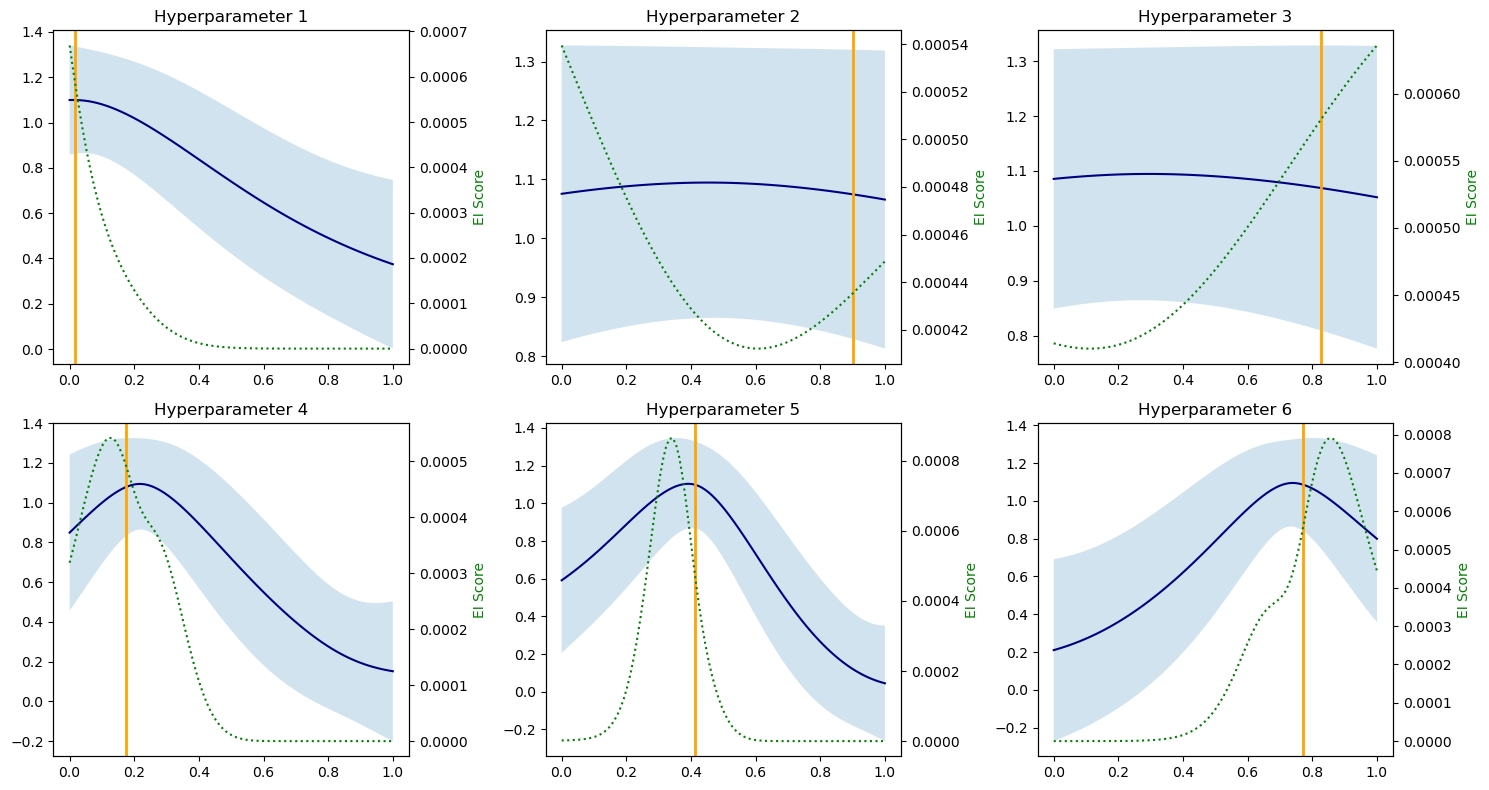

In [32]:
def plot_slice_with_acquisition(gp, X_data, y_data, next_x):
    best_idx = np.argmax(y_data)
    best_x = X_data[best_idx]
    y_max = np.max(y_data)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    x_range = np.linspace(0, 1, 100)

    for i in range(6):
        ax = axes[i]
        X_slice = np.tile(best_x, (100, 1))
        X_slice[:, i] = x_range
        
        # 1. Get GP Prediction
        mu, sigma = gp.predict(X_slice, return_std=True)
        
        # 2. Calculate EI (Acquisition) for this slice
        # (Using the simple version of your EI function)
        from scipy.stats import norm
        z = (mu - y_max) / sigma
        ei = (mu - y_max) * norm.cdf(z) + sigma * norm.pdf(z)

        # Plot GP Mean
        ax.plot(x_range, mu, color='navy', label='GP Mean')
        ax.fill_between(x_range, mu - 1.96*sigma, mu + 1.96*sigma, alpha=0.2)
        
        # Plot Acquisition Score on a twin axis
        ax2 = ax.twinx()
        ax2.plot(x_range, ei, color='green', linestyle=':', label='EI Score')
        ax2.set_ylabel('EI Score', color='green')
        
        # Mark the NEW Suggestion
        ax.axvline(next_x[i], color='orange', lw=2, label='Next Suggestion')
        ax.set_title(f"Hyperparameter {i+1}")

    plt.tight_layout()
    plt.show()

# Run the plotting function
plot_slice_with_acquisition(gp, X, y, ucb_next_query)

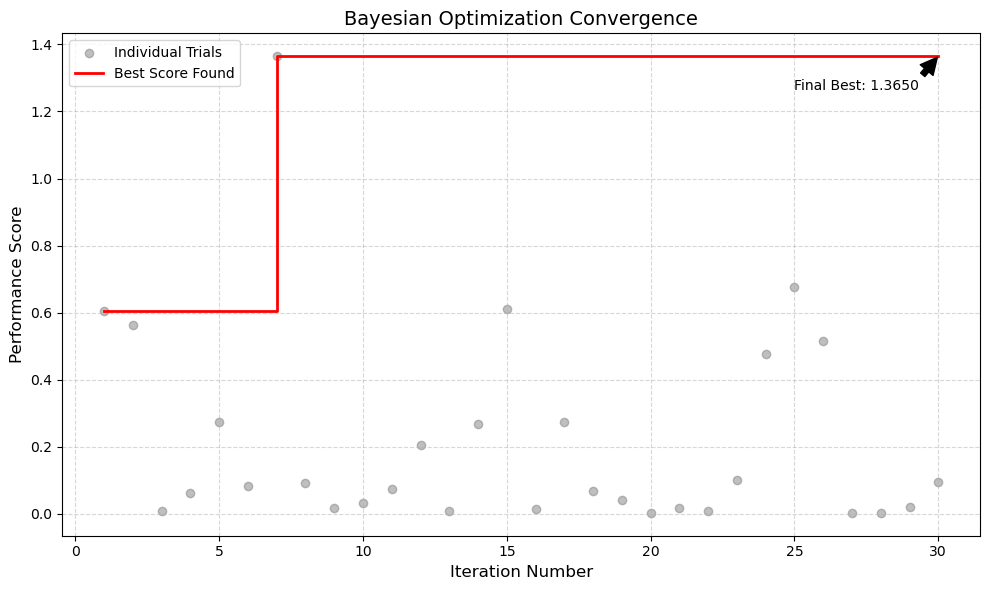

In [34]:
import matplotlib.pyplot as plt
import numpy as np

def plot_convergence(y_data):
    # 1. Calculate the 'Running Maximum'
    # This shows the best score discovered up to each iteration
    running_max = np.maximum.accumulate(y_data)
    iterations = np.arange(1, len(y_data) + 1)

    plt.figure(figsize=(10, 6))
    
    # 2. Plot the individual observations (the "noise")
    plt.scatter(iterations, y_data, color='gray', alpha=0.5, label='Individual Trials')
    
    # 3. Plot the staircase (the "progress")
    plt.step(iterations, running_max, where='post', color='red', lw=2, label='Best Score Found')
    
    # Formatting
    plt.title("Bayesian Optimization Convergence", fontsize=14)
    plt.xlabel("Iteration Number", fontsize=12)
    plt.ylabel("Performance Score", fontsize=12)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend()
    
    # Optional: Mark the final best value
    plt.annotate(f'Final Best: {running_max[-1]:.4f}', 
                 xy=(iterations[-1], running_max[-1]), 
                 xytext=(iterations[-1]-5, running_max[-1]-0.1),
                 arrowprops=dict(facecolor='black', shrink=0.05))

    plt.tight_layout()
    plt.show()

# Run the plot
plot_convergence(y)

In [ ]:
# Final Submission Checklist
# With the 6-Panel Slices and this Convergence Plot, you have:
# Proof of Sensitivity: Which parameters matter (4, 5, 6).
# Proof of Strategy: Why you picked the next point (Acquisition Peak).
# Proof of Success: How the score improved over time (Convergence).